## IMPORT LIBRARIES

In [206]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.model_selection import RandomizedSearchCV

# Classification models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

## READ DATASET

In [207]:
transdata = pd.read_csv("card_transdata.csv")
transdata.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


## EDA

In [208]:
transdata.shape

(1000000, 8)

In [209]:
transdata.dtypes

distance_from_home                float64
distance_from_last_transaction    float64
ratio_to_median_purchase_price    float64
repeat_retailer                   float64
used_chip                         float64
used_pin_number                   float64
online_order                      float64
fraud                             float64
dtype: object

In [210]:
transdata.isna().sum()

distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

In [211]:
transdata.describe()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182,0.881536,0.350399,0.100608,0.650552,0.087403
std,65.390784,25.843093,2.799589,0.323157,0.477095,0.300809,0.476796,0.282425
min,0.004874,0.000118,0.004399,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.878008,0.296671,0.475673,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.967760,0.998650,0.997717,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.743985,3.355748,2.096370,1.000000,1.000000,0.000000,1.000000,0.000000
max,10632.723672,11851.104565,267.802942,1.000000,1.000000,1.000000,1.000000,1.000000


In [212]:
transdata.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [213]:
transdata.duplicated().sum()

np.int64(0)

## DEFINE FEATURES AND TARGET

In [214]:
features = transdata.drop(columns = ["fraud"])
target = transdata["fraud"]


## SPLIT TRAIN AND TEST

In [215]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.20, random_state=29, stratify=target)

In [216]:
X_train.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order
984675,25.765687,0.349869,1.978979,1.0,0.0,0.0,1.0
9524,8.324646,0.236116,1.668811,1.0,1.0,0.0,1.0
615515,1.594954,1.286077,0.638216,0.0,1.0,0.0,0.0
894774,57.000553,7.396652,1.197155,1.0,0.0,1.0,0.0
550067,21.492142,3.390010,0.972146,1.0,0.0,0.0,1.0


In [217]:
y_train.head()

984675    0.0
9524      0.0
615515    0.0
894774    0.0
550067    0.0
Name: fraud, dtype: float64

## FEATURE SELECTION

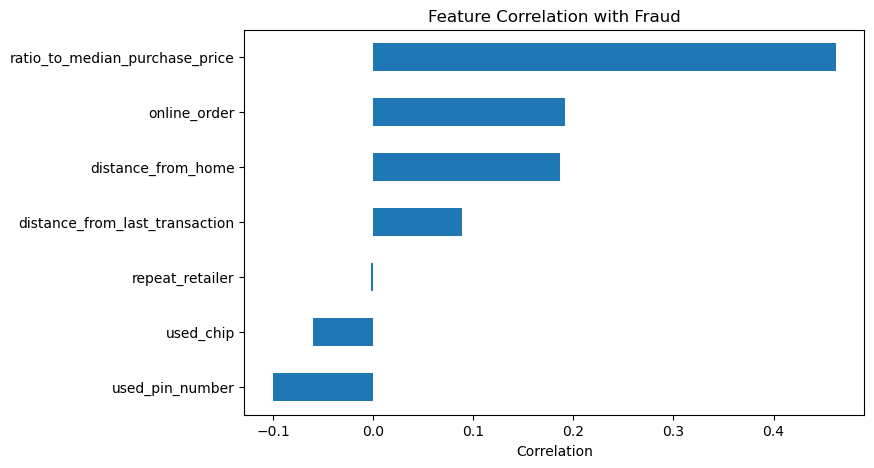

In [218]:
correlations = X_train.corrwith(y_train).sort_values()

plt.figure(figsize=(8,5))
correlations.plot(kind="barh")
plt.title("Feature Correlation with Fraud")
plt.xlabel("Correlation")
plt.show()

## FEATURE SCALING

In [219]:
from sklearn.preprocessing import MinMaxScaler

normalizer = MinMaxScaler()

# Fit only on the training data
normalizer.fit(X_train)

# Transform the training data
X_train_norm = normalizer.transform(X_train)
X_train_norm = pd.DataFrame(
    X_train_norm,
    columns=X_train.columns,
    index=X_train.index
)

# Transform the test data
X_test_norm = normalizer.transform(X_test)
X_test_norm = pd.DataFrame(
    X_test_norm,
    columns=X_test.columns,
    index=X_test.index
)

In [220]:
## Feature selection was performed using correlation analysis on the training dataset. The variable ratio_to_median_purchase_price 
## showed the strongest positive correlation with the target variable (fraud), indicating that transactions with unusually 
## high purchase-price ratios are more likely to be fraudulent. online_order and distance_from_home also displayed moderate 
## positive correlations. The remaining variables showed weak or near-zero linear correlations; however, they were retained because 
## tree-based machine learning models can capture nonlinear relationships and feature interactions that are not reflected by Pearson 
## correlation alone.

## BALANCING THE SAMPLE

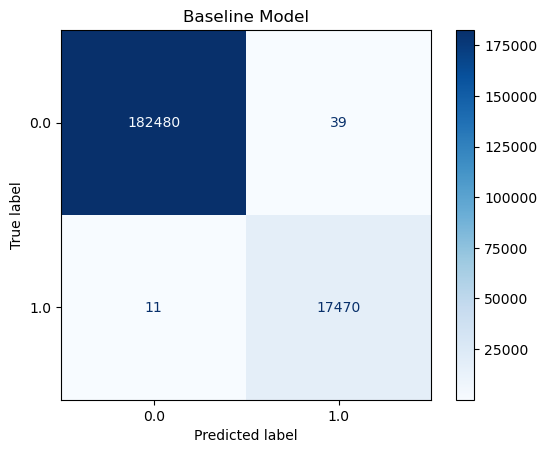

In [118]:
## LOGISTIC REGRESSION AS BASELINE MODEL

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    cmap="Blues"
)

plt.title("Baseline Model")
plt.show()

In [120]:
train_df = X_train_norm.copy()

train_df["fraud"] = y_train.values

# Separate classes
fraud_positive = train_df[train_df["fraud"] == 1]
fraud_negative = train_df[train_df["fraud"] == 0]

In [123]:
# Oversample minority class
fraud_positive_oversampled = resample(
    fraud_positive,
    replace=True,
    n_samples=len(fraud_negative),
    random_state=42
)

# Combine majority class with oversampled minority class
fraud_over = pd.concat([
    fraud_negative,
    fraud_positive_oversampled
])

# Check new class balance
print(fraud_over["fraud"].value_counts())

fraud
0.0    730078
1.0    730078
Name: count, dtype: int64


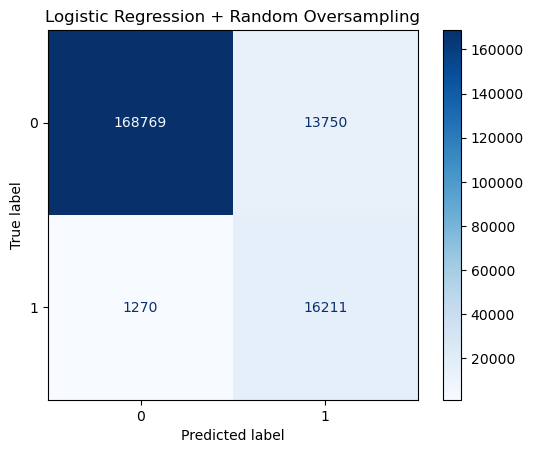

In [124]:
# Split oversampled features and target
X_train_over = fraud_over.drop(columns=["fraud"])
y_train_over = fraud_over["fraud"]

# Train Logistic Regression with oversampled data
oversampled_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

oversampled_model.fit(X_train_over, y_train_over)

# Predict on the ORIGINAL normalized test set
oversampled_pred = oversampled_model.predict(X_test_norm)

# Confusion matrix
cm = confusion_matrix(y_test, oversampled_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("Logistic Regression + Random Oversampling")
plt.show()

fraud
0.0    730078
1.0    730078
Name: count, dtype: int64


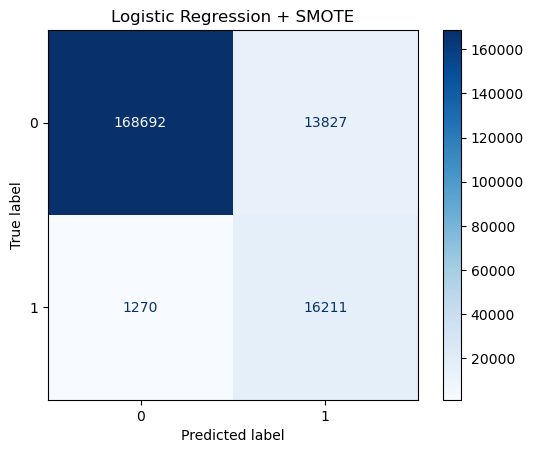

In [126]:
## SMOTE

# Apply SMOTE to the normalized training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_norm,
    y_train
)

# Check new class balance
print(pd.Series(y_train_smote).value_counts())

# Train Logistic Regression with SMOTE data
smote_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_model.fit(X_train_smote, y_train_smote)

# Predict on the ORIGINAL normalized test set
smote_pred = smote_model.predict(X_test_norm)

# Predicted probabilities (for ROC-AUC)
smote_proba = smote_model.predict_proba(X_test_norm)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, smote_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("Logistic Regression + SMOTE")
plt.show()


## MODEL TRAINING AND EVALUATION

In [221]:
results = []

In [222]:
## KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_norm, y_train)

pred = knn.predict(X_test_norm)

# Get predicted probabilities for the positive class (fraud = 1)
proba = knn.predict_proba(X_test_norm)[:, 1]

# Metrics
print("Accuracy:", accuracy_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred))

results.append({
    "Model": "KNN",
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred),
    "Recall": recall_score(y_test, pred),
    "F1-score": f1_score(y_test, pred),
    "ROC-AUC": roc_auc_score(y_test, proba)
})

Accuracy: 0.99904
ROC-AUC: 0.999024281415265
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    182519
         1.0       1.00      0.99      0.99     17481

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



In [223]:
## Logistic Regression

log_reg = LogisticRegression(random_state=42)

log_reg.fit(X_train_norm, y_train)

pred = log_reg.predict(X_test_norm)
proba = log_reg.predict_proba(X_test_norm)[:, 1]

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred))

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred),
    "Recall": recall_score(y_test, pred),
    "F1-score": f1_score(y_test, pred),
    "ROC-AUC": roc_auc_score(y_test, proba)
})



Accuracy: 0.944835
ROC-AUC: 0.9516791780130738
              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97    182519
         1.0       0.91      0.41      0.56     17481

    accuracy                           0.94    200000
   macro avg       0.93      0.70      0.77    200000
weighted avg       0.94      0.94      0.93    200000



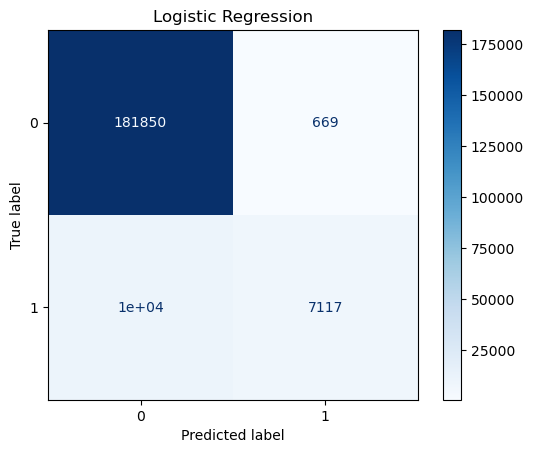

False Negatives: 10364
False Positives: 669


In [224]:
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("Logistic Regression")
plt.show()

tn, fp, fn, tp = cm.ravel()
print("False Negatives:", fn)
print("False Positives:", fp)

In [225]:
## Decision Tree

tree = DecisionTreeClassifier(
    max_depth=20,
    random_state=42
)

tree.fit(X_train, y_train)

pred = tree.predict(X_test)
proba = tree.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred))

results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred),
    "Recall": recall_score(y_test, pred),
    "F1-score": f1_score(y_test, pred),
    "ROC-AUC": roc_auc_score(y_test, proba)
})

Accuracy: 0.99999
ROC-AUC: 0.9999686580764793
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    182519
         1.0       1.00      1.00      1.00     17481

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



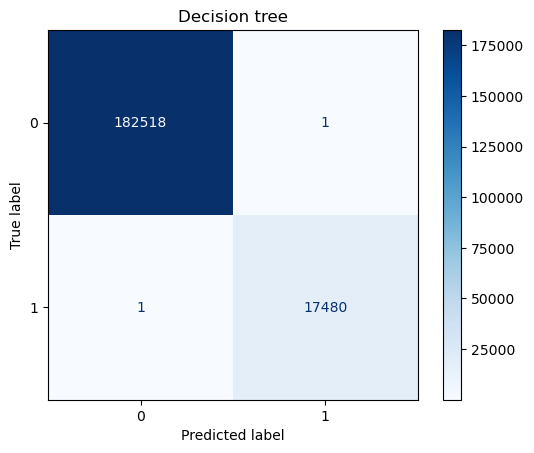

False Negatives: 1
False Positives: 1


In [226]:
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("Decision tree")
plt.show()

tn, fp, fn, tp = cm.ravel()
print("False Negatives:", fn)
print("False Positives:", fp)

In [227]:
## Random Forest

forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42
)

forest.fit(X_train, y_train)

pred = forest.predict(X_test)
proba = forest.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred))

results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred),
    "Recall": recall_score(y_test, pred),
    "F1-score": f1_score(y_test, pred),
    "ROC-AUC": roc_auc_score(y_test, proba)
})

Accuracy: 0.99999
ROC-AUC: 0.9999999984329038
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    182519
         1.0       1.00      1.00      1.00     17481

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



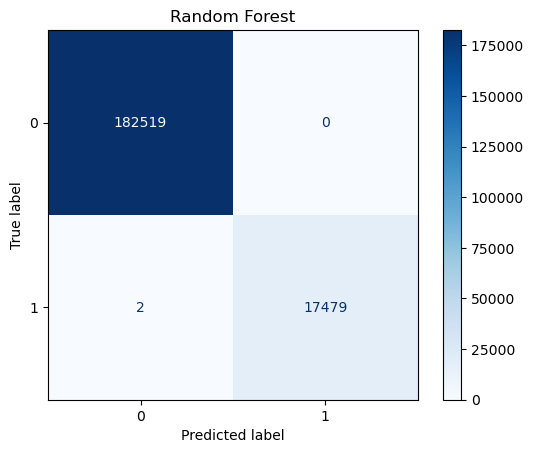

False Negatives: 2
False Positives: 0


In [228]:
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("Random Forest")
plt.show()

tn, fp, fn, tp = cm.ravel()
print("False Negatives:", fn)
print("False Positives:", fp)

In [229]:
## Bagging

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=20),
    n_estimators=100,
    random_state=42
)

bagging.fit(X_train, y_train)

pred = bagging.predict(X_test)
proba = bagging.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred))

results.append({
    "Model": "Bagging",
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred),
    "Recall": recall_score(y_test, pred),
    "F1-score": f1_score(y_test, pred),
    "ROC-AUC": roc_auc_score(y_test, proba)
})

Accuracy: 0.99999
ROC-AUC: 0.9999713951666602
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    182519
         1.0       1.00      1.00      1.00     17481

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



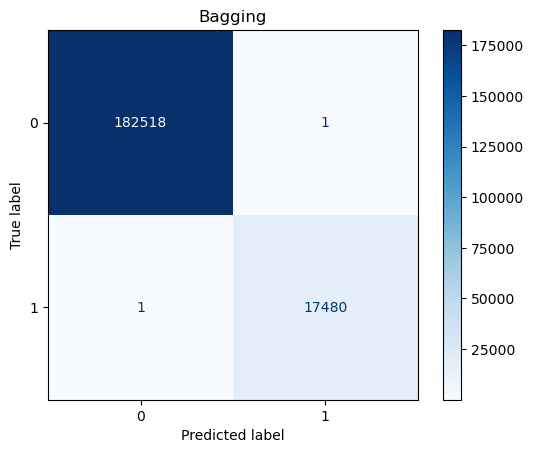

False Negatives: 1
False Positives: 1


In [230]:
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("Bagging")
plt.show()

tn, fp, fn, tp = cm.ravel()
print("False Negatives:", fn)
print("False Positives:", fp)

In [231]:
## Gradient boosting

gradient = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gradient.fit(X_train, y_train)

pred = gradient.predict(X_test)
proba = gradient.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred))

results.append({
    "Model": "Gradient boosting",
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred),
    "Recall": recall_score(y_test, pred),
    "F1-score": f1_score(y_test, pred),
    "ROC-AUC": roc_auc_score(y_test, proba)
})

Accuracy: 0.999835
ROC-AUC: 0.9999803971939338
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    182519
         1.0       1.00      1.00      1.00     17481

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



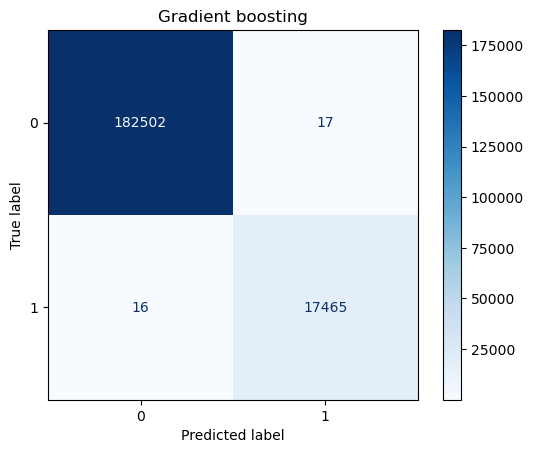

False Negatives: 16
False Positives: 17


In [232]:
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("Gradient boosting")
plt.show()

tn, fp, fn, tp = cm.ravel()
print("False Negatives:", fn)
print("False Positives:", fp)

In [233]:
## AdaBoost

ada = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada.fit(X_train, y_train)

pred = ada.predict(X_test)
proba = ada.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred))

results.append({
    "Model": "AdaBoost",
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred),
    "Recall": recall_score(y_test, pred),
    "F1-score": f1_score(y_test, pred),
    "ROC-AUC": roc_auc_score(y_test, proba)
})

Accuracy: 0.99975
ROC-AUC: 0.999979072684246
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    182519
         1.0       1.00      1.00      1.00     17481

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



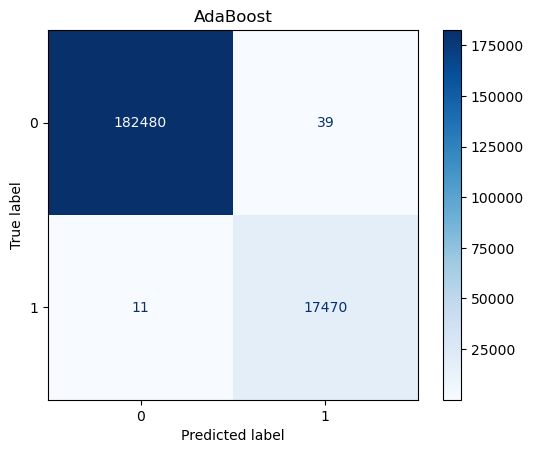

False Negatives: 11
False Positives: 39


In [234]:
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("AdaBoost")
plt.show()

tn, fp, fn, tp = cm.ravel()
print("False Negatives:", fn)
print("False Positives:", fp)

## MODEL SELECTION AND COMPARISON

In [235]:
comparison = pd.DataFrame(results)

comparison = comparison.sort_values(
    by="Recall",
    ascending=False
)

comparison.round(7)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,Decision Tree,0.999990,0.999943,0.999943,0.999943,0.999969
4,Bagging,0.999990,0.999943,0.999943,0.999943,0.999971
3,Random Forest,0.999990,1.000000,0.999886,0.999943,1.000000
6,AdaBoost,0.999750,0.997773,0.999371,0.998571,0.999979
5,Gradient boosting,0.999835,0.999028,0.999085,0.999056,0.999980
0,KNN,0.999040,0.996041,0.992964,0.994500,0.999024
1,Logistic Regression,0.944835,0.914076,0.407128,0.563343,0.951679


In [236]:
# Seven classification algorithms were evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC. Since the objective of fraud 
# detection is to minimize false negatives, Recall was considered the primary evaluation metric. 
# Bagging and Decision Tree achieved the highest Recall (0.999943), correctly identifying almost all fraudulent transactions. 
# Between these two models, Bagging was selected because it achieved the same Recall and F1-score while obtaining a slightly 
# higher ROC-AUC (0.999971 vs. 0.999969), indicating marginally better overall discrimination between fraudulent and legitimate 
# transactions.

## HYPERPARAMETER TUNING

In [237]:
## CHANGE THRESHOLD

# BAGGING
proba = bagging.predict_proba(X_test)[:, 1]

thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

for t in thresholds:
    pred_t = (proba >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, pred_t).ravel()

    print(f"\nThreshold = {t}")
    print(f"Precision: {precision_score(y_test, pred_t):.6f}")
    print(f"Recall: {recall_score(y_test, pred_t):.6f}")
    print(f"False Negatives: {fn}")
    print(f"False Positives: {fp}")

pred_threshold = (proba >= threshold).astype(int)

print("Threshold:", threshold)
print("Accuracy:", accuracy_score(y_test, pred_threshold))
print("Precision:", precision_score(y_test, pred_threshold))
print("Recall:", recall_score(y_test, pred_threshold))
print("F1-score:", f1_score(y_test, pred_threshold))
print("ROC-AUC:", roc_auc_score(y_test, proba))  # ROC-AUC uses probabilities

print(classification_report(y_test, pred_threshold))




Threshold = 0.5
Precision: 0.999943
Recall: 0.999943
False Negatives: 1
False Positives: 1

Threshold = 0.4
Precision: 0.999886
Recall: 0.999943
False Negatives: 1
False Positives: 2

Threshold = 0.3
Precision: 0.999828
Recall: 0.999943
False Negatives: 1
False Positives: 3

Threshold = 0.2
Precision: 0.999828
Recall: 0.999943
False Negatives: 1
False Positives: 3

Threshold = 0.1
Precision: 0.999828
Recall: 0.999943
False Negatives: 1
False Positives: 3
Threshold: 0.3
Accuracy: 0.99998
Precision: 0.9998284047360293
Recall: 0.999942795034609
F1-score: 0.9998855966136597
ROC-AUC: 0.9999713951666602
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    182519
         1.0       1.00      1.00      1.00     17481

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



In [238]:
## DECISION TREE

tree_proba = tree.predict_proba(X_test)[:, 1]

thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

for t in thresholds:
    pred_t = (proba >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, pred_t).ravel()

    print(f"\nThreshold = {t}")
    print(f"Precision: {precision_score(y_test, pred_t):.6f}")
    print(f"Recall: {recall_score(y_test, pred_t):.6f}")
    print(f"False Negatives: {fn}")
    print(f"False Positives: {fp}")

pred_threshold = (proba >= threshold).astype(int)

print("Threshold:", threshold)
print("Accuracy:", accuracy_score(y_test, pred_threshold))
print("Precision:", precision_score(y_test, pred_threshold))
print("Recall:", recall_score(y_test, pred_threshold))
print("F1-score:", f1_score(y_test, pred_threshold))
print("ROC-AUC:", roc_auc_score(y_test, proba))  # ROC-AUC uses probabilities

print(classification_report(y_test, pred_threshold))


Threshold = 0.5
Precision: 0.999943
Recall: 0.999943
False Negatives: 1
False Positives: 1

Threshold = 0.4
Precision: 0.999886
Recall: 0.999943
False Negatives: 1
False Positives: 2

Threshold = 0.3
Precision: 0.999828
Recall: 0.999943
False Negatives: 1
False Positives: 3

Threshold = 0.2
Precision: 0.999828
Recall: 0.999943
False Negatives: 1
False Positives: 3

Threshold = 0.1
Precision: 0.999828
Recall: 0.999943
False Negatives: 1
False Positives: 3
Threshold: 0.3
Accuracy: 0.99998
Precision: 0.9998284047360293
Recall: 0.999942795034609
F1-score: 0.9998855966136597
ROC-AUC: 0.9999713951666602
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    182519
         1.0       1.00      1.00      1.00     17481

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



In [239]:
## RANDOM FOREST
proba = forest.predict_proba(X_test)[:, 1]

thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

for t in thresholds:
    pred_t = (proba >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, pred_t).ravel()

    print(f"\nThreshold = {t}")
    print(f"Precision: {precision_score(y_test, pred_t):.6f}")
    print(f"Recall: {recall_score(y_test, pred_t):.6f}")
    print(f"False Negatives: {fn}")
    print(f"False Positives: {fp}")

pred_threshold = (proba >= threshold).astype(int)

print("Threshold:", threshold)
print("Accuracy:", accuracy_score(y_test, pred_threshold))
print("Precision:", precision_score(y_test, pred_threshold))
print("Recall:", recall_score(y_test, pred_threshold))
print("F1-score:", f1_score(y_test, pred_threshold))
print("ROC-AUC:", roc_auc_score(y_test, proba))  # ROC-AUC uses probabilities

print(classification_report(y_test, pred_threshold))



Threshold = 0.5
Precision: 1.000000
Recall: 0.999886
False Negatives: 2
False Positives: 0

Threshold = 0.4
Precision: 1.000000
Recall: 0.999943
False Negatives: 1
False Positives: 0

Threshold = 0.3
Precision: 1.000000
Recall: 0.999943
False Negatives: 1
False Positives: 0

Threshold = 0.2
Precision: 0.999771
Recall: 0.999943
False Negatives: 1
False Positives: 4

Threshold = 0.1
Precision: 0.998515
Recall: 1.000000
False Negatives: 0
False Positives: 26
Threshold: 0.3
Accuracy: 0.999995
Precision: 1.0
Recall: 0.999942795034609
F1-score: 0.9999713966991791
ROC-AUC: 0.9999999984329038
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    182519
         1.0       1.00      1.00      1.00     17481

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



## CROSS VALIDATION

In [240]:
## BAGGING

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    bagging,
    features,
    target,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    n_jobs=-1
)

print("Cross-Validation Results (5-Fold)\n")

for metric in cv_results:
    if metric.startswith("test_"):
        print(f"{metric[5:]}: {cv_results[metric].mean():.6f} ± {cv_results[metric].std():.6f}")

Cross-Validation Results (5-Fold)

accuracy: 0.999989 ± 0.000008
precision: 0.999977 ± 0.000028
recall: 0.999897 ± 0.000092
f1: 0.999937 ± 0.000046
roc_auc: 0.999989 ± 0.000014


In [241]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

false_negatives = []

for train_idx, test_idx in cv.split(features, target):
    X_train_cv = features.iloc[train_idx]
    X_test_cv = features.iloc[test_idx]
    y_train_cv = target.iloc[train_idx]
    y_test_cv = target.iloc[test_idx]

    bagging = BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=20),
        n_estimators=100,
        random_state=42
    )

    bagging.fit(X_train_cv, y_train_cv)

    pred_cv = bagging.predict(X_test_cv)

    tn, fp, fn, tp = confusion_matrix(y_test_cv, pred_cv).ravel()
    false_negatives.append(fn)

print("False negatives per fold:", false_negatives)
print("Maximum false negatives:", max(false_negatives))
print("Average false negatives:", np.mean(false_negatives))

False negatives per fold: [np.int64(3), np.int64(0), np.int64(2), np.int64(4), np.int64(0)]
Maximum false negatives: 4
Average false negatives: 1.8


In [242]:
## RANDOM FOREST:

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results_rf = cross_validate(
    rf,
    features,
    target,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    n_jobs=-1
)

for metric in cv_results_rf:
    if metric.startswith("test"):
        print(
            f"{metric}: "
            f"{cv_results_rf[metric].mean():.6f} ± "
            f"{cv_results_rf[metric].std():.6f}"
        )

test_accuracy: 0.999992 ± 0.000007
test_precision: 1.000000 ± 0.000000
test_recall: 0.999908 ± 0.000078
test_f1: 0.999954 ± 0.000039
test_roc_auc: 1.000000 ± 0.000000


## CONCLUSIONS